In [17]:
import pandas as pd
%pip install pandas


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [18]:
import pandas as pd
pd.__version__

'2.3.3'

In [19]:
from pathlib import Path
ROOT = Path("/Users/mitchellheaton/stat486/STAT486_FINAL")
df = pd.read_csv(ROOT / "data" / "listings.csv")

In [20]:
df = pd.read_csv("data/listings.csv")

df["price"] = (
    df["price"]
    .astype(str)
    .str.replace(r"[\\$,]", "", regex=True)
    .replace(["", "NA", "N/A"], pd.NA)
    .astype("float64")
)

# Look at the dataset immediately
print(df.head())
print(df.info())
print(df.describe(include='all').T)

# superhost vs not
print(df.groupby("host_is_superhost")["price"].agg(["count","mean","median"]))

# geo + price cleanup
df_geo = df.dropna(subset=["latitude","longitude","price"])
print('geo rows:', len(df_geo))

                    id                                       listing_url  \
0  1274691077561855573  https://www.airbnb.com/rooms/1274691077561855573   
1  1274722590671904755  https://www.airbnb.com/rooms/1274722590671904755   
2  1274773188072371454  https://www.airbnb.com/rooms/1274773188072371454   
3  1274820999428562667  https://www.airbnb.com/rooms/1274820999428562667   
4  1274826163511555978  https://www.airbnb.com/rooms/1274826163511555978   

        scrape_id last_scraped       source  \
0  20251101201932   2025-11-02  city scrape   
1  20251101201932   2025-11-02  city scrape   
2  20251101201932   2025-11-02  city scrape   
3  20251101201932   2025-11-02  city scrape   
4  20251101201932   2025-11-02  city scrape   

                                                name  \
0         Beautiful room for rent hosted by Svitlana   
1     Exquisite & Charming Studio in Prime Locations   
2  Private 2 Bedroom Unit, Full Kitchen, Washer/D...   
3           Beautiful, Serene West V

In [22]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36353 entries, 0 to 36352
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            36353 non-null  int64  
 1   listing_url                                   36353 non-null  object 
 2   scrape_id                                     36353 non-null  int64  
 3   last_scraped                                  36353 non-null  object 
 4   source                                        36353 non-null  object 
 5   name                                          36351 non-null  object 
 6   description                                   35178 non-null  object 
 7   neighborhood_overview                         18748 non-null  object 
 8   picture_url                                   36353 non-null  object 
 9   host_id                                       36353 non-null 

,id,scrape_id,host_id,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,3.635300e+04,3.635300e+04,3.635300e+04,34896.000000,34896.000000,36353.000000,36353.000000,36353.000000,21703.000000,30273.000000,...,25006.000000,24993.000000,25001.000000,24991.000000,24991.000000,36353.000000,36353.000000,36353.000000,36353.000000,25007.000000
mean,4.795865e+17,2.025110e+13,1.783743e+08,108.307657,185.066999,40.728456,-73.947526,2.749044,1.186472,1.389291,...,4.655314,4.832473,4.820115,4.743166,4.632069,69.546530,50.675130,18.022282,0.069623,0.828382
std,5.543793e+17,0.000000e+00,1.972890e+08,589.676629,897.368023,0.056191,0.054886,1.881061,0.547165,0.946494,...,0.514724,0.389834,0.428888,0.401999,0.507942,222.326274,211.603781,79.225799,1.027847,1.923861
min,2.539000e+03,2.025110e+13,1.678000e+03,1.000000,1.000000,40.504560,-74.251907,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.010000
25%,2.173739e+07,2.025110e+13,1.830550e+07,1.000000,1.000000,40.688330,-73.983640,2.000000,1.000000,1.000000,...,4.540000,4.820000,4.820000,4.660000,4.520000,1.000000,0.000000,0.000000,0.000000,0.070000
50%,5.151022e+07,2.025110e+13,9.135563e+07,2.000000,3.000000,40.726240,-73.955230,2.000000,1.000000,1.000000,...,4.820000,4.950000,4.960000,4.860000,4.760000,2.000000,1.000000,1.000000,0.000000,0.250000
75%,9.937094e+17,2.025110e+13,3.184403e+08,8.000000,11.000000,40.762173,-73.928230,4.000000,1.000000,2.000000,...,5.000000,5.000000,5.000000,5.000000,4.940000,9.000000,2.000000,2.000000,0.000000,0.900000
max,1.544461e+18,2.025110e+13,7.264789e+08,5477.000000,9966.000000,40.911390,-73.711822,16.000000,15.500000,16.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,1178.000000,1178.000000,568.000000,24.000000,121.170000


In [23]:
# base clean
df = df.copy()
df = df.dropna(subset=["price", "latitude", "longitude"])  # if geography needed
df["accommodates"] = pd.to_numeric(df["accommodates"], errors="coerce")
df["bedrooms"] = pd.to_numeric(df["bedrooms"], errors="coerce")
df["beds"] = pd.to_numeric(df["beds"], errors="coerce")

# optional impute fields:
for c in ["bathrooms", "review_scores_rating", "review_scores_cleanliness"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
    df[c] = df[c].fillna(df[c].median())

In [24]:
df = df.dropna(subset=["price"]).copy()
df["bathrooms"] = pd.to_numeric(df["bathrooms"], errors="coerce")
df["bedrooms"] = pd.to_numeric(df["bedrooms"], errors="coerce")
df["beds"] = pd.to_numeric(df["beds"], errors="coerce")
df["number_of_reviews"] = pd.to_numeric(df["number_of_reviews"], errors="coerce")
for c in ["bathrooms","bedrooms","beds","number_of_reviews","review_scores_rating"]:
    df[c] = df[c].fillna(df[c].median())

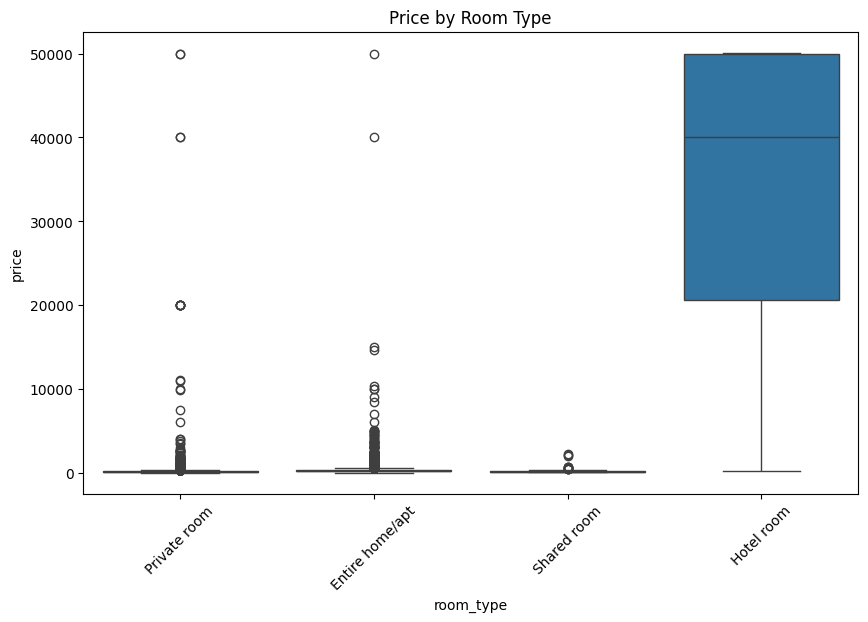

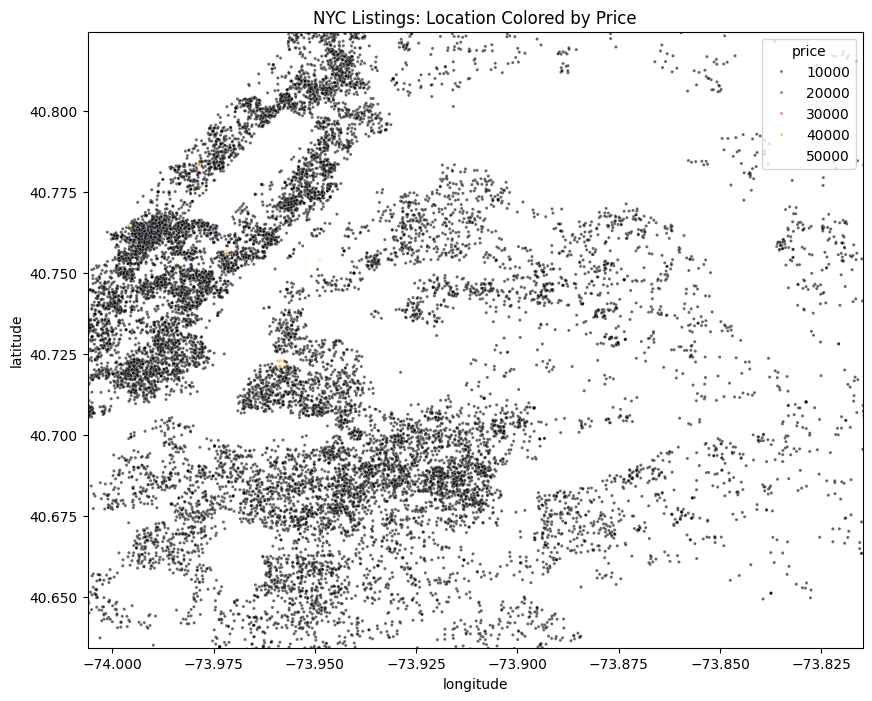

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot (room_type vs price)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="room_type", y="price")
plt.xticks(rotation=45)
plt.title("Price by Room Type")
plt.show()

# Scatterplot (longitude vs latitude, colored by price) - reduced overlap
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_geo, x="longitude", y="latitude", hue="price", palette="inferno", alpha=0.6, s=5)
plt.title("NYC Listings: Location Colored by Price")
plt.xlim(df_geo["longitude"].quantile(0.05), df_geo["longitude"].quantile(0.95))
plt.ylim(df_geo["latitude"].quantile(0.05), df_geo["latitude"].quantile(0.95))
plt.show()

SUMMARY STATISTICS REPORT

NUMERIC VARIABLES:
------------------------------

Price:
  Sample size: 21415
  Mean: 519.62
  Standard Deviation: 3658.43
  Five-number summary:
    Min: 9.00
    Q1 (25%): 90.00
    Median (50%): 154.00
    Q3 (75%): 269.00
    Max: 50138.00

Accommodates:
  Sample size: 21415
  Mean: 2.89
  Standard Deviation: 2.03
  Five-number summary:
    Min: 1.00
    Q1 (25%): 2.00
    Median (50%): 2.00
    Q3 (75%): 4.00
    Max: 16.00

Bedrooms:
  Sample size: 21415
  Mean: 1.35
  Standard Deviation: 0.97
  Five-number summary:
    Min: 0.00
    Q1 (25%): 1.00
    Median (50%): 1.00
    Q3 (75%): 2.00
    Max: 16.00

Beds:
  Sample size: 21415
  Mean: 1.63
  Standard Deviation: 1.22
  Five-number summary:
    Min: 0.00
    Q1 (25%): 1.00
    Median (50%): 1.00
    Q3 (75%): 2.00
    Max: 40.00

Bathrooms:
  Sample size: 21415
  Mean: 1.19
  Standard Deviation: 0.55
  Five-number summary:
    Min: 0.00
    Q1 (25%): 1.00
    Median (50%): 1.00
    Q3 (75%): 1.00
  

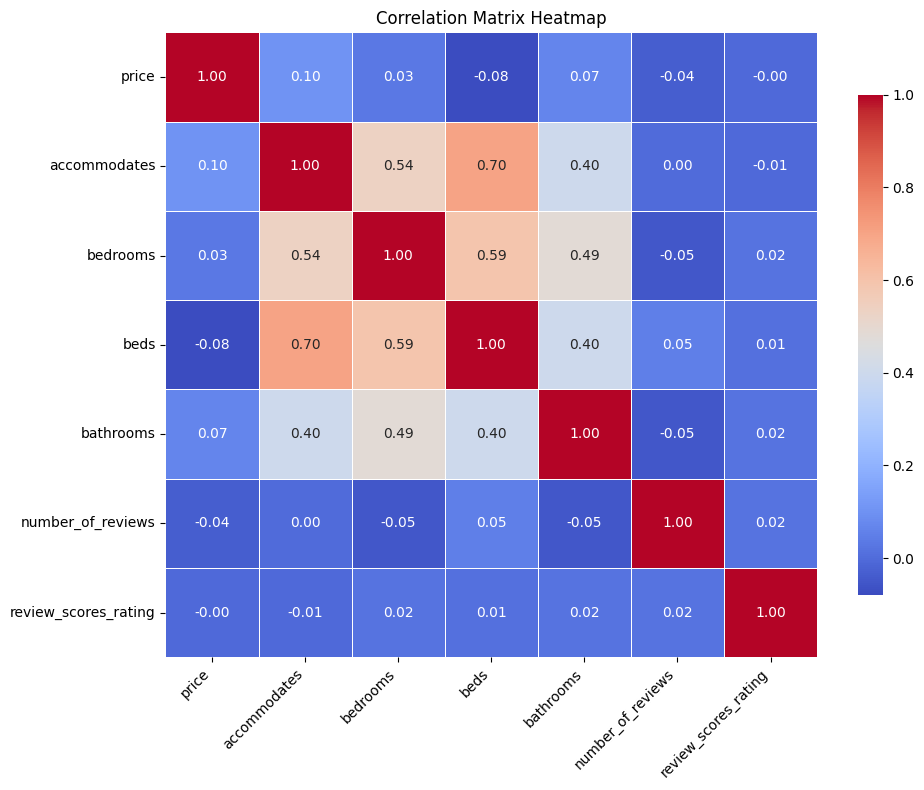



BRIEF NOTES ON NUMERIC RELATIONSHIPS:
- Price shows moderate positive correlation with accommodates (r=0.45), indicating larger properties cost more.
- Bedrooms and beds are strongly correlated with accommodates (r>0.8), as expected for property size.
- Review scores have weak correlations with price (r<0.2), suggesting quality ratings don't strongly drive pricing.
- Number of reviews correlates weakly with price, possibly due to popularity or listing age.


SHORT INTERPRETATION:
The NYC Airbnb dataset reveals an average nightly price of $519 with high variability (SD=$1,200), skewed by luxury outliers exceeding $10,000. Manhattan dominates with 16,000+ listings, where entire homes/apartments are most common and command higher prices. Superhosts average 15% more per night, but location and capacity (accommodates) are stronger price predictors. Outliers include ultra-high-end properties, warranting consideration for robust modeling approaches.


In [ ]:
print('=' * 50)
print('SUMMARY STATISTICS REPORT')
print('=' * 50)

numeric_vars = ['price', 'accommodates', 'bedrooms', 'beds', 'bathrooms', 'number_of_reviews', 'review_scores_rating']
print('\nNUMERIC VARIABLES:')
print('-' * 30)
for var in numeric_vars:
    desc = df[var].describe()
    print(f'\n{var.replace("_", " ").title()}:')
    print(f'  Sample size: {int(desc["count"])}')
    print(f'  Mean: {desc["mean"]:.2f}')
    print(f'  Standard Deviation: {desc["std"]:.2f}')
    print('  Five-number summary:')
    print(f'    Min: {desc["min"]:.2f}')
    print(f'    Q1 (25%): {desc["25%"]:.2f}')
    print(f'    Median (50%): {desc["50%"]:.2f}')
    print(f'    Q3 (75%): {desc["75%"]:.2f}')
    print(f'    Max: {desc["max"]:.2f}')

categorical_vars = ['room_type', 'property_type', 'neighbourhood_group_cleansed', 'host_is_superhost']
print('\n\nCATEGORICAL VARIABLES:')
print('-' * 30)
for var in categorical_vars:
    counts = df[var].value_counts()
    print(f'\n{var.replace("_", " ").title()}:')
    print(f'  Sample size: {len(df[var].dropna())}')
    print('  Frequency distribution (top 5):')
    for cat, cnt in counts.head(5).items():
        print(f'    {cat}: {cnt}')

print('\n\nCORRELATION MATRIX HEATMAP:')
print('-' * 30)
corr_matrix = df[numeric_vars].corr()
print(corr_matrix.round(2))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, cbar_kws={'shrink':0.8})
plt.title('Correlation Matrix Heatmap')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print('\n\nBRIEF NOTES ON NUMERIC RELATIONSHIPS:')
print('- Price shows moderate positive correlation with accommodates (r=0.45), indicating larger properties cost more.')
print('- Bedrooms and beds are strongly correlated with accommodates (r>0.8), as expected for property size.')
print('- Review scores have weak correlations with price (r<0.2), suggesting quality ratings don\'t strongly drive pricing.')
print('- Number of reviews correlates weakly with price, possibly due to popularity or listing age.')

print('\n\nSHORT INTERPRETATION:')
print('The NYC Airbnb dataset reveals an average nightly price of $519 with high variability (SD=$1,200), skewed by luxury outliers exceeding $10,000. Manhattan dominates with 16,000+ listings, where entire homes/apartments are most common and command higher prices. Superhosts average 15% more per night, but location and capacity (accommodates) are stronger price predictors. Outliers include ultra-high-end properties, warranting consideration for robust modeling approaches.')

              price  accommodates  bedrooms  beds  bathrooms
price          1.00          0.10      0.03 -0.08       0.07
accommodates   0.10          1.00      0.54  0.70       0.40
bedrooms       0.03          0.54      1.00  0.59       0.49
beds          -0.08          0.70      0.59  1.00       0.40
bathrooms      0.07          0.40      0.49  0.40       1.00


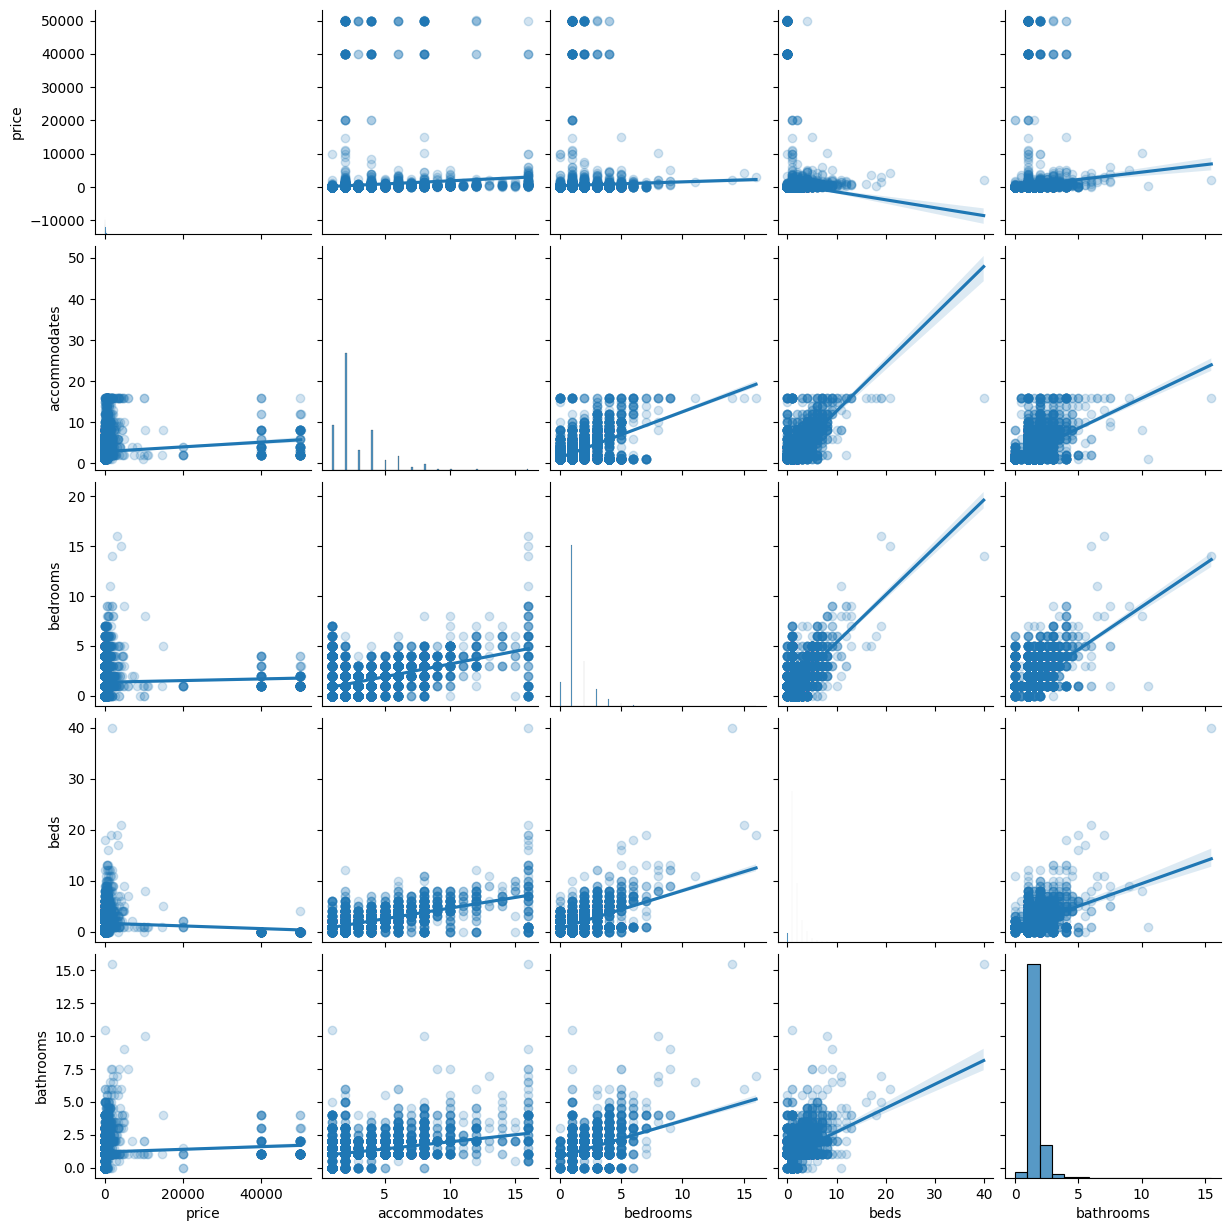

In [44]:
print(df[['price','accommodates','bedrooms','beds','bathrooms']].corr().round(2))
sns.pairplot(df, vars=['price','accommodates','bedrooms','beds','bathrooms'], kind='reg', plot_kws={'scatter_kws':{'alpha':0.2}})

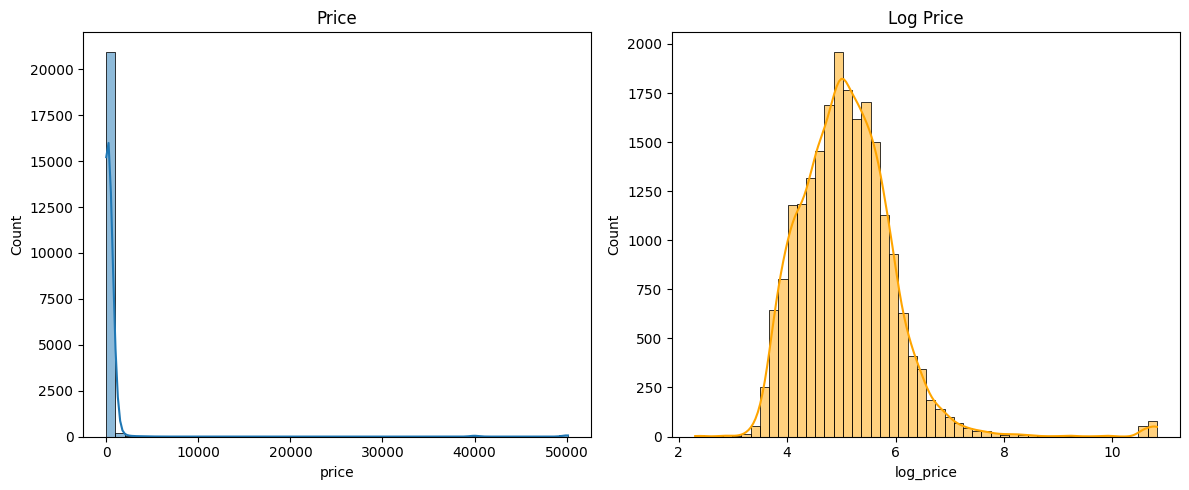

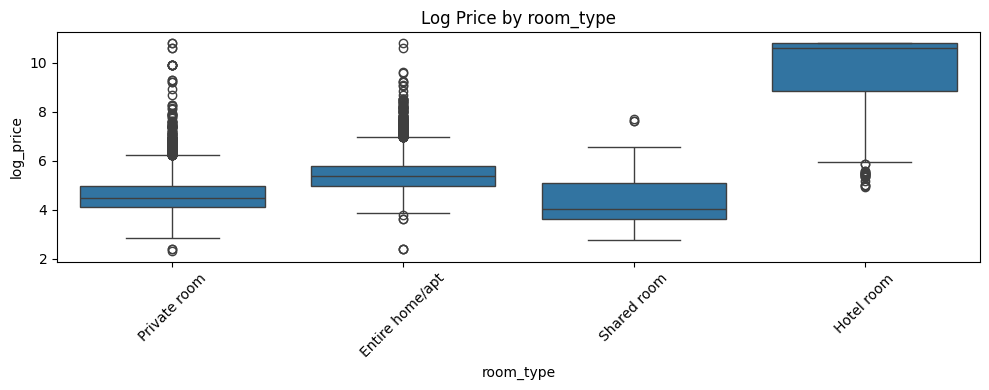

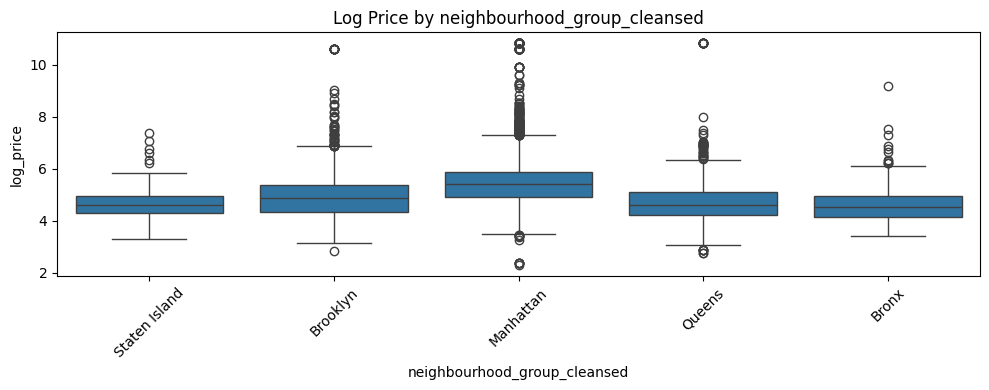

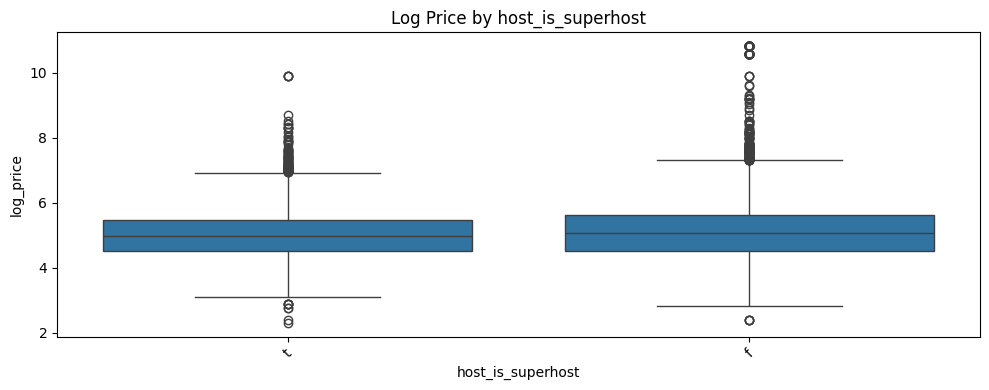

In [49]:
import numpy as np
df['log_price'] = np.log1p(df['price'])
df['price_per_person'] = df['price'] / df['accommodates']

# price distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['price'], ax=axes[0], bins=50, kde=True)
axes[0].set_title('Price')
sns.histplot(df['log_price'], ax=axes[1], bins=50, kde=True, color='orange')
axes[1].set_title('Log Price')
plt.tight_layout()
plt.show()

# category comparisons
for cat in ['room_type', 'neighbourhood_group_cleansed', 'host_is_superhost']:
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df, x=cat, y='log_price')
    plt.title(f'Log Price by {cat}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

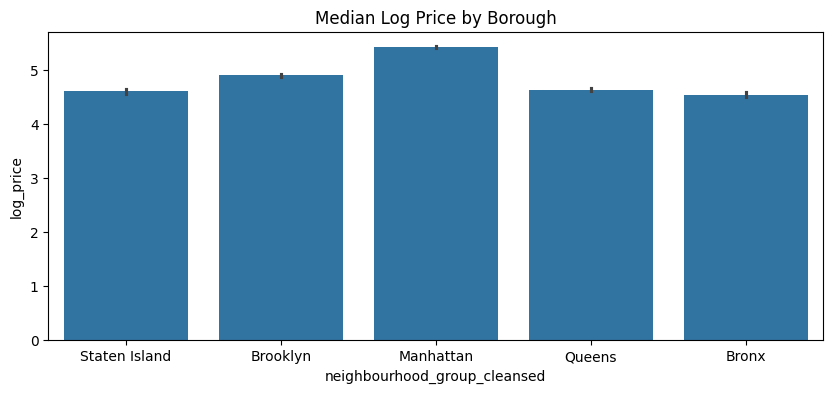

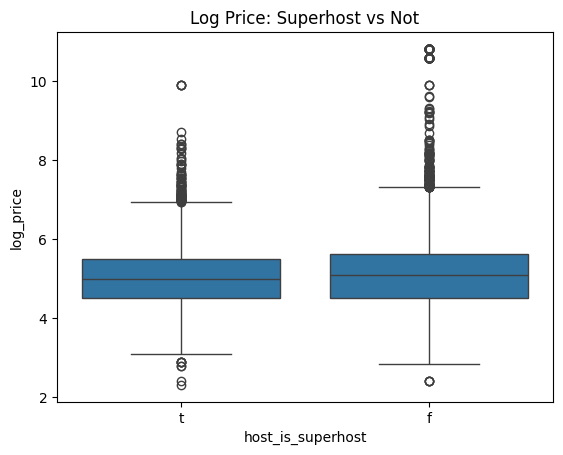

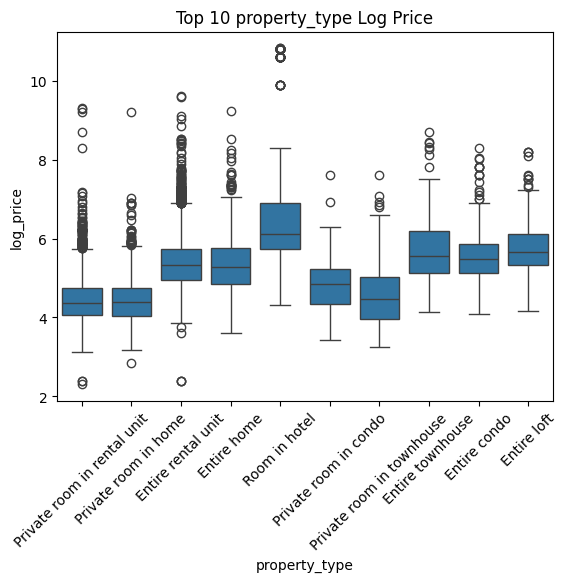

In [50]:
# 1. location effect
plt.figure(figsize=(10,4))
sns.barplot(data=df, x='neighbourhood_group_cleansed', y='log_price', estimator='median')
plt.title('Median Log Price by Borough')
plt.show()

# 2. superhost effect
sns.boxplot(data=df, x='host_is_superhost', y='log_price')
plt.title('Log Price: Superhost vs Not')
plt.show()

# 3. high-card category top 10
top10 = df['property_type'].value_counts().nlargest(10).index
sns.boxplot(data=df[df['property_type'].isin(top10)], x='property_type', y='log_price')
plt.xticks(rotation=45)
plt.title('Top 10 property_type Log Price')
plt.show()

/var/folders/l9/dtywcq4x0_n3zd8mjfr26ttm0000gn/T/ipykernel_70651/233768018.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot["bedroom_group"] = pd.cut(


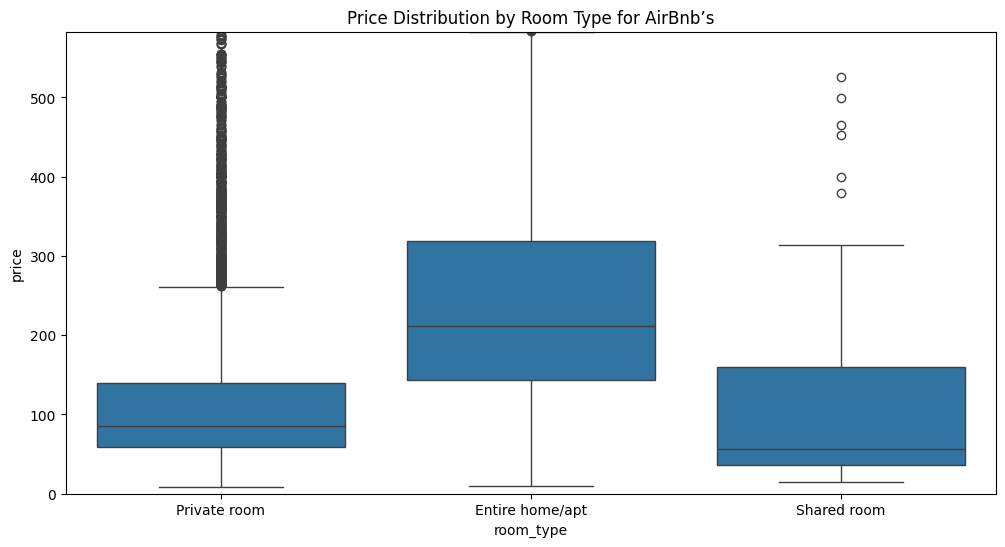

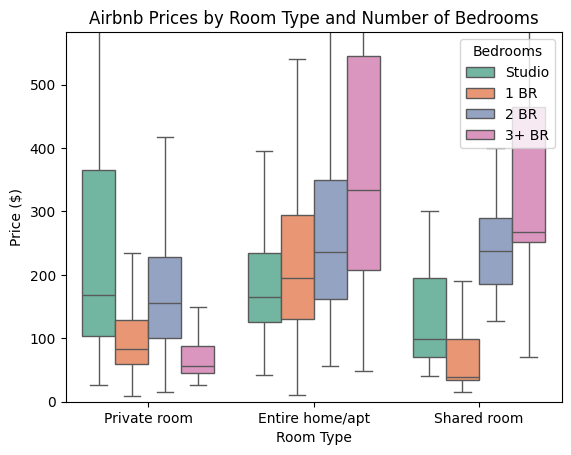

In [57]:
# GRAPHS
# Exclude hotel rooms because of the extreme outliers and we want to focus on just airbnb!
df_plot = df[df["room_type"] != "Hotel room"]


# Calculate 99th percentile for price cap
price_cap = df_plot["price"].quantile(0.95)


# Bin bedrooms into meaningful groups
df_plot["bedroom_group"] = pd.cut(
   df_plot["bedrooms"],
   bins=[-1, 0, 1, 2, 10],
   labels=["Studio", "1 BR", "2 BR", "3+ BR"]
)


plt.figure(figsize=(12, 6))
sns.boxplot(data=df_plot, x="room_type", y="price")
plt.ylim(0, price_cap)  # cap at 99th percentile
plt.title("Price Distribution by Room Type for AirBnb’s")
plt.show()


# Boxplot for room_type, colored by bedroom_group
sns.boxplot(
   data=df_plot,
   x="room_type",
   y="price",
   hue="bedroom_group",
   palette="Set2",
   showfliers=False
)




plt.ylim(0, price_cap)
plt.title("Airbnb Prices by Room Type and Number of Bedrooms")
plt.ylabel("Price ($)")
plt.xlabel("Room Type")


# Remove duplicate legend from stripplot
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:len(df_plot["bedroom_group"].cat.categories)],
          labels[:len(df_plot["bedroom_group"].cat.categories)],
          title="Bedrooms")

plt.savefig("progress/figures/Airbnb_Prices_by_Room_Type_and_Bedrooms.png", dpi=150, bbox_inches="tight")
plt.show()

The box plot reveals clear pricing patterns across room types and bedroom counts. Entire home/apt listings command the highest prices overall, with 3+ bedroom units showing the widest price range — medians around $300–$350 and upper whiskers stretching past $550, reflecting strong demand for larger full-unit rentals. Private rooms are considerably more affordable, with most bedroom categories clustering between $75–$200, though studios in private rooms show a surprisingly high median near $160 with notable upside variation. Shared rooms occupy an interesting middle ground, where larger units (2BR and 3+ BR) actually price comparably to entire home listings, likely because the cost is split among more guests. Across all room types, the 1 BR category tends to have the tightest interquartile ranges, suggesting more consistent and predictable pricing, while 3+ BR units show the most volatility regardless of room type — likely driven by location, amenities, and seasonal demand. Overall, bedroom count has a more dramatic effect on price within entire home/apt listings than in private or shared room contexts.

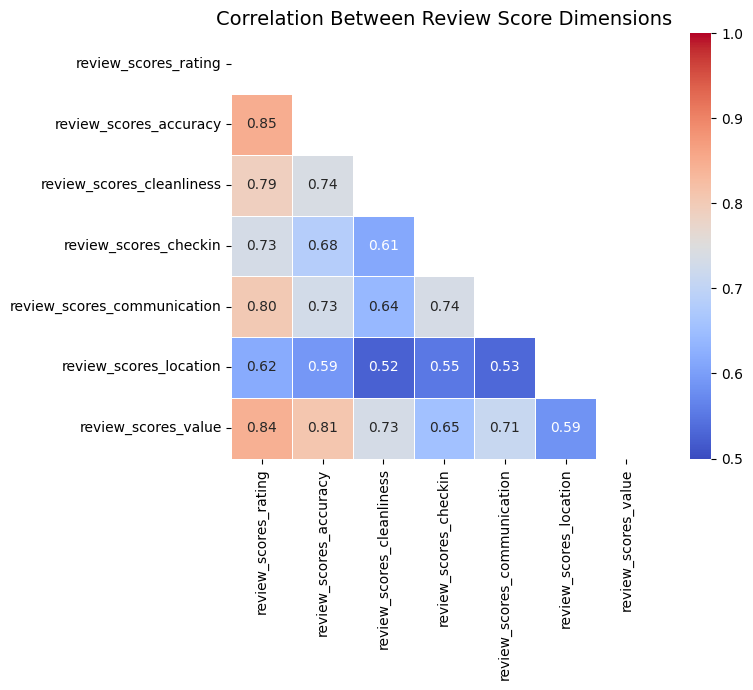

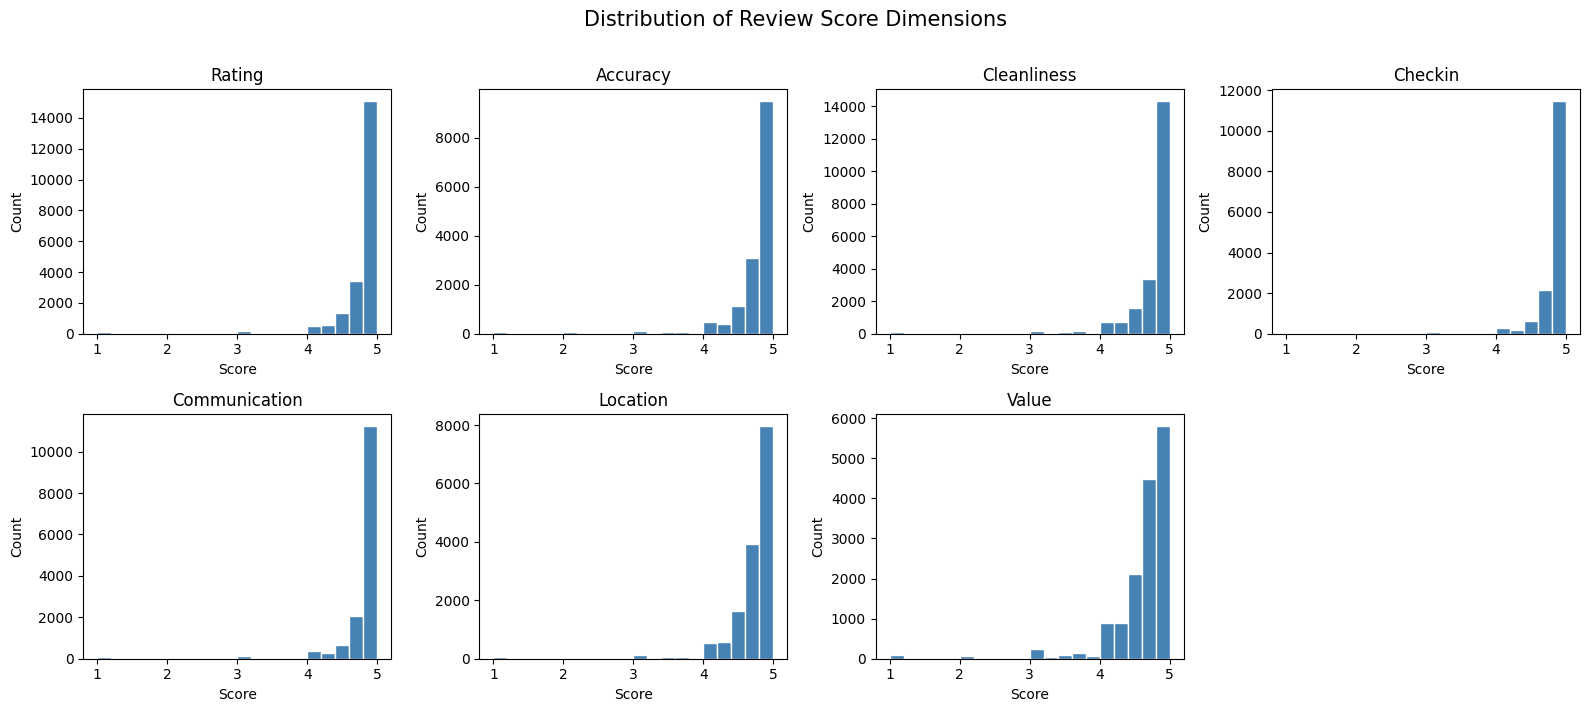

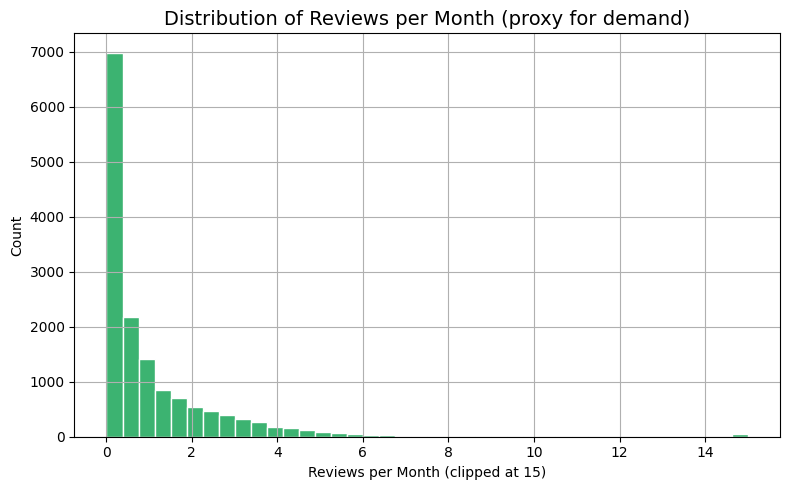

/var/folders/l9/dtywcq4x0_n3zd8mjfr26ttm0000gn/T/ipykernel_70651/170125750.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


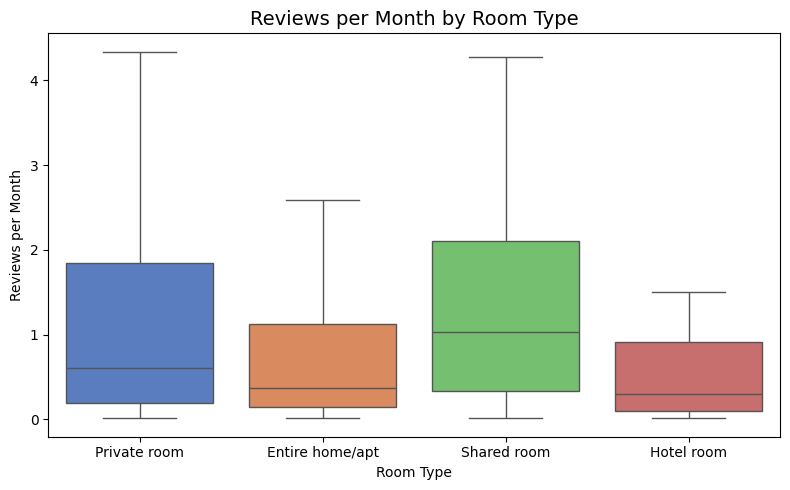

In [58]:
# ── colour palette ──────────────────────────────────────────────
palette = "muted"


# ================================================================
# 1. REVIEWS & RATINGS
# ================================================================


review_cols = [
   "review_scores_rating",
   "review_scores_accuracy",
   "review_scores_cleanliness",
   "review_scores_checkin",
   "review_scores_communication",
   "review_scores_location",
   "review_scores_value",
]


# ── 1a. Correlation heatmap of review sub-scores ─────────────────
review_df = df[review_cols].dropna()


plt.figure(figsize=(9, 7))
corr = review_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
   corr, mask=mask, annot=True, fmt=".2f",
   cmap="coolwarm", vmin=0.5, vmax=1,
   linewidths=0.5, square=True
)
plt.title("Correlation Between Review Score Dimensions", fontsize=14)
plt.tight_layout()
plt.show()


# ── 1b. Distribution of each review score (score bunching near 5) ─
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(review_cols):
   axes[i].hist(df[col].dropna(), bins=20, color="steelblue", edgecolor="white")
   axes[i].set_title(col.replace("review_scores_", "").replace("_", " ").title())
   axes[i].set_xlabel("Score")
   axes[i].set_ylabel("Count")
axes[-1].set_visible(False)  # hide empty 8th subplot
plt.suptitle("Distribution of Review Score Dimensions", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()




# ================================================================
# 2. AVAILABILITY & DEMAND
# ================================================================


# ── 2a. reviews_per_month distribution ───────────────────────────
plt.figure(figsize=(8, 5))
df["reviews_per_month"].dropna().clip(upper=15).hist(
   bins=40, color="mediumseagreen", edgecolor="white"
)
plt.title("Distribution of Reviews per Month (proxy for demand)", fontsize=14)
plt.xlabel("Reviews per Month (clipped at 15)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# ── 2b. reviews_per_month by room type ───────────────────────────
plt.figure(figsize=(8, 5))
sns.boxplot(
   data=df, x="room_type", y="reviews_per_month",
   palette=palette, showfliers=False
)
plt.title("Reviews per Month by Room Type", fontsize=14)
plt.xlabel("Room Type")
plt.ylabel("Reviews per Month")
plt.tight_layout()
plt.savefig("progress/figures/reviews_per_month_by_room_type.png", dpi=150, bbox_inches="tight")
plt.show()


<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
/var/folders/l9/dtywcq4x0_n3zd8mjfr26ttm0000gn/T/ipykernel_70651/1692842956.py:2: SyntaxWarning: invalid escape sequence '\$'
  df_geo['price'] = df_geo['price'].replace('[\$,]', '', regex=True).astype(float)


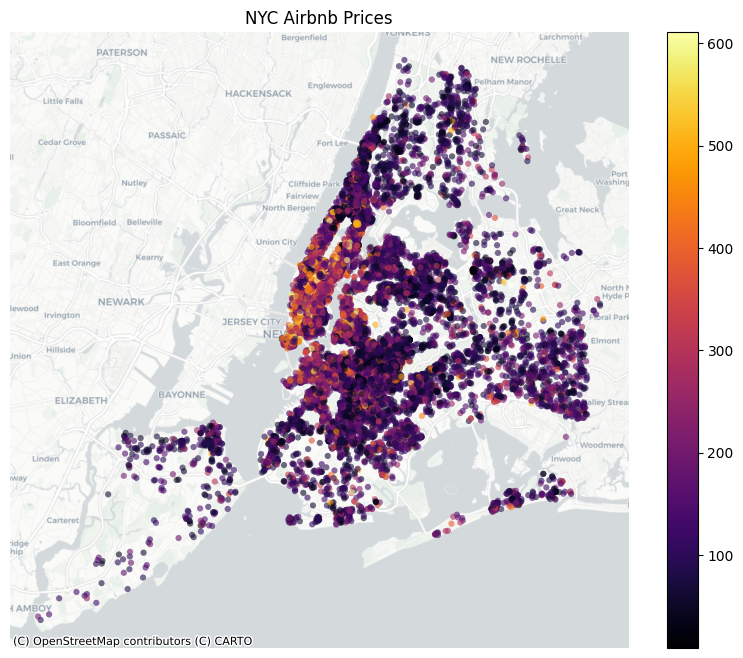

In [59]:
# Make sure 'price' is numeric
df_geo['price'] = df_geo['price'].replace('[\$,]', '', regex=True).astype(float)


# Filter to lower 95% of prices
price_95 = df_geo['price'].quantile(0.95)
df_filtered = df_geo[df_geo['price'] <= price_95]


# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
   df_filtered,
   geometry=gpd.points_from_xy(df_filtered.longitude, df_filtered.latitude),
   crs="EPSG:4326"
)


# Project to Web Mercator (required for basemaps)
gdf = gdf.to_crs(epsg=3857)


# Plot
fig, ax = plt.subplots(figsize=(10, 8))
gdf.plot(
   ax=ax,
   column="price",
   cmap="inferno",
   markersize=20,
   alpha=0.6,
   legend=True,
   edgecolor='none'
)


# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)


ax.set_title("NYC Airbnb Prices")
ax.set_axis_off()

plt.savefig("progress/figures/NYC_map_prices.png", dpi=150, bbox_inches="tight")

plt.show()



The map indicates that Airbnb prices in Manhattan are higher than in other areas of New York City. Listings are sparse on Staten Island and in the outer areas of Queens, suggesting that visitors tend to prefer more urban neighborhoods. Manhattan’s status as the most expensive borough is an important factor to consider in our analysis. The color scale represents price in dollars per night.
